# A Six-Mirror EUV Projection Objective — from Patent Prescription to Printed Wafer

**US 7,151,592 B2** (Hudyma, Mann, Dinger — Carl Zeiss SMT), Embodiment 1.
PNPPNP · NA(image) = 0.22 · 4× reduction · λ = 13.4 nm · 1500 mm track.

This notebook is fully self-contained. It:

1. **Defines the optical system** exactly from the patent tables (radii, conics,
   aspheric polynomial coefficients, spacings).
2. **Ray-traces** it with an exact (non-paraxial) sequential tracer:
   Newton intersection of aspheres + vector reflection law.
3. **Validates** the tracer to machine precision on analytic conics.
4. **Recovers the correction.** The 5-significant-figure patent coefficients
   are too coarse to carry the λ/100 wavefront; we refit the polynomial terms
   (radii/conics/spacings held fixed) by damped least squares.
5. **Extracts the exit-pupil wavefront** (the eikonal / OPD over the pupil).
6. **Propagates to the wafer** with scalar partially-coherent (Abbe) imaging
   and prints a lithographic test pattern.
7. **Quantifies resolving power** (contrast vs. half-pitch → diffraction cutoff).

### Framework for light
- **Objective:** geometrical optics (the eikonal limit of Maxwell). Rays carry
  optical path length only; no wavelength, no polarization.
- **Wafer image:** scalar diffraction (Fourier optics, Hopkins/Abbe partial
  coherence). One complex scalar field; no vector **E**/**H** components.
- A closing section sketches the **vectorial (Jones-pupil / Richards–Wolf)**
  upgrade — negligible at NA 0.22 (~NA² ≈ 5 %), dominant at High-NA 0.55.

> **Sign / unit conventions** (Code V / Zemax sequential): global fixed z-axis;
> `R > 0` ⇒ center of curvature toward +z; thickness negative after an odd
> number of reflections; all lengths in **millimetres**.


## 0 · Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq, least_squares
from scipy.interpolate import griddata

np.set_printoptions(precision=4, suppress=False, linewidth=120)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})

## 1 · Definition of the optical system

Each mirror is a rotationally-symmetric conic + even-polynomial surface,
described by its vertex radius $R$, conic constant $K$, and six-term
even-asphere deformation $(A,B,C,D,E)$ multiplying $h^4,h^6,h^8,h^{10},h^{12}$
where $h^2=x^2+y^2$:

$$
s(h)=\frac{c\,h^{2}}{1+\sqrt{1-(1+K)c^{2}h^{2}}}
      +A h^{4}+B h^{6}+C h^{8}+D h^{10}+E h^{12},\qquad c=\frac1R .
$$

The **axial vertex positions** are accumulated from the patent thickness
column. The aperture **stop** lies between M1 and M2; a real **intermediate
image** forms between M2 and M3.

In [2]:
# Aspheric coefficients (A,B,C,D,E) — verbatim from US7151592B2 Table 2
MIRRORS = [
    dict(name="M1", R=-643.5439,   K=-1.0232,
         AE=[ 2.3506e-09, -5.2889e-14,  1.1199e-18, -2.2037e-23,  4.1964e-28]),
    dict(name="M2", R=-2742.4833,  K=-207.7484,
         AE=[ 1.0280e-09,  2.5446e-14,  6.3412e-18, -2.2982e-21,  3.2649e-25]),
    dict(name="M3", R=-2850.8680,  K=-3.9282,
         AE=[ 1.0123e-10,  8.1343e-17, -1.5369e-20,  3.5192e-25, -3.4955e-30]),
    dict(name="M4", R= 1471.8440,  K= 0.1886,
         AE=[ 1.9835e-11, -1.8278e-16,  2.1374e-21, -1.4503e-26,  5.3855e-32]),
    dict(name="M5", R=  252.1454,  K= 0.9822,
         AE=[-1.3413e-08,  9.1993e-13, -2.2661e-17, -5.9605e-22,  2.6224e-25]),
    dict(name="M6", R=  558.1165,  K= 0.0814,
         AE=[-2.4749e-11, -5.9262e-17, -1.2870e-23, -1.4070e-26,  6.3467e-31]),
]

# Axial vertex positions from the thickness column (mm)
Z = {"OB": 0.0}
Z["M1"]  = Z["OB"] + 723.7539
Z["APE"] = Z["M1"] - 192.7897     # aperture stop
Z["M2"]  = Z["APE"] - 99.4340
Z["IMI"] = Z["M2"] + 363.1533     # intermediate image
Z["M3"]  = Z["IMI"] + 343.7066
Z["M4"]  = Z["M3"] - 644.4521
Z["M5"]  = Z["M4"] + 971.0620
Z["M6"]  = Z["M5"] - 475.4847
Z["IM"]  = Z["M6"] + 510.4847     # wafer / image plane
for m in MIRRORS:
    m["zv"] = Z[m["name"]]

WAVEL = 13.4e-6      # mm
NAO   = 0.055        # object-side numerical aperture (patent)
NAI   = 4 * NAO      # image-side NA = 0.22
FIELDS = [116.0, 120.0, 124.0]    # ring-field object heights (mm)

print(f"total track OB->IM = {Z['IM']:.1f} mm   NA(image) = {NAI:.2f}")
for k in ["M1","APE","M2","IMI","M3","M4","M5","M6","IM"]:
    print(f"  {k:4s} z = {Z[k]:9.4f} mm")

total track OB->IM = 1500.0 mm   NA(image) = 0.22
  M1   z =  723.7539 mm
  APE  z =  530.9642 mm
  M2   z =  431.5302 mm
  IMI  z =  794.6835 mm
  M3   z = 1138.3901 mm
  M4   z =  493.9380 mm
  M5   z = 1465.0000 mm
  M6   z =  989.5153 mm
  IM   z = 1500.0000 mm


## 2 · Surface mathematics

The sag $s(h)$, its slope $s'(h)$ (for surface normals and the Newton
derivative), the exact ray–surface intersection, the unit normal from
$\nabla F$ with $F=z-z_v-s(h)$, and the vector reflection law.

In [3]:
def sag(m, h2):
    """Sag z(h) of conic + even polynomial;  h2 = h^2."""
    c = 1.0/m["R"]; k = m["K"]; A,B,C,D,E = m["AE"]
    s = c*h2 / (1.0 + np.sqrt(1.0 - (1.0+k)*c*c*h2))
    return s + h2*h2*(A + h2*(B + h2*(C + h2*(D + h2*E))))

def dsag_dh(m, h):
    """d(sag)/dh."""
    c = 1.0/m["R"]; k = m["K"]; A,B,C,D,E = m["AE"]; h2 = h*h
    ds = c*h / np.sqrt(1.0 - (1.0+k)*c*c*h2)
    ds += 4*A*h**3 + 6*B*h**5 + 8*C*h**7 + 10*D*h**9 + 12*E*h**11
    return ds

def intersect(m, p, d):
    """Exact Newton intersection of ray p + t d with z = zv + sag(h)."""
    t = (m["zv"] - p[2]) / d[2]                 # seed: vertex plane
    for _ in range(60):
        q  = p + t*d
        h2 = q[0]*q[0] + q[1]*q[1]
        F  = q[2] - m["zv"] - sag(m, h2)
        h  = np.sqrt(h2)
        dz = dsag_dh(m, h) if h > 1e-12 else 0.0
        dhdt = (q[0]*d[0] + q[1]*d[1]) / h if h > 1e-12 else 0.0
        dF = d[2] - dz*dhdt                     # dF/dt
        dt = -F/dF; t += dt
        if abs(dt) < 1e-13:
            break
    return p + t*d

def normal(m, q):
    """Unit surface normal (grad F), +z hemisphere."""
    h = np.hypot(q[0], q[1])
    if h < 1e-12:
        n = np.array([0.0, 0.0, 1.0])
    else:
        dz = dsag_dh(m, h)
        n  = np.array([-dz*q[0]/h, -dz*q[1]/h, 1.0])
    return n/np.linalg.norm(n)

def reflect(d, n):
    """Vector reflection law."""
    return d - 2.0*np.dot(d, n)*n

## 3 · Sequential ray tracer

`trace` returns the full poly-line (for layout), the angle of incidence on
each mirror, and the direction + point at the wafer. `trace_opl` additionally
accumulates optical path length (all reflections in vacuum ⇒ OPL = geometric
length) — this is the eikonal we need for the wavefront.

In [4]:
def trace(p0, d0):
    p, d = np.array(p0, float), np.array(d0, float); d /= np.linalg.norm(d)
    path = [p.copy()]; aois = []
    for m in MIRRORS:
        q = intersect(m, p, d); n = normal(m, q)
        aois.append(np.degrees(np.arccos(min(1.0, abs(np.dot(d, n))))))
        d = reflect(d, n); p = q; path.append(p.copy())
    t = (Z["IM"] - p[2]) / d[2]
    pim = p + t*d; path.append(pim.copy())
    return path, aois, d, pim

def trace_opl(p0, d0):
    p, d = np.array(p0, float), np.array(d0, float); d /= np.linalg.norm(d)
    L = 0.0
    for m in MIRRORS:
        q = intersect(m, p, d); L += np.linalg.norm(q - p)
        n = normal(m, q); d = reflect(d, n); p = q
    t = (Z["IM"] - p[2]) / d[2]
    return L + t, p + t*d, d

### 3.1 · The chief ray as a root-finding problem

The patent fixes the stop between M1 and M2 but not the launch angle. For each
field height we solve for the object-space angle $\theta$ whose ray, after M1,
crosses the axis exactly at the stop plane $z=z_\mathrm{APE}$.

In [5]:
def stop_miss(theta, yobj):
    p = np.array([0.0, yobj, 0.0])
    d = np.array([0.0, np.sin(theta), np.cos(theta)])
    q = intersect(MIRRORS[0], p, d); n = normal(MIRRORS[0], q)
    d2 = reflect(d, n)
    t = (Z["APE"] - q[2]) / d2[2]
    return (q + t*d2)[1]           # y-height at the stop plane

def find_chief(yobj):
    return brentq(lambda t: stop_miss(t, yobj), -0.3, 0.05, xtol=1e-15)

for y in FIELDS:
    th = find_chief(y)
    _, aois, dim, pim = trace([0, y, 0], [0, np.sin(th), np.cos(th)])
    tele = np.degrees(np.arccos(abs(dim[2])))
    print(f"y={y:6.1f} mm | chief {abs(np.degrees(th)):.2f}° | "
          f"y'={pim[1]:8.4f} mm | mag={pim[1]/y:+.4f} | "
          f"AOI={[f'{a:.1f}' for a in aois]}")

y= 116.0 mm | chief 5.50° | y'= 29.0626 mm | mag=+0.2505 | AOI=['9.6', '14.2', '10.7', '4.3', '10.8', '3.0']
y= 120.0 mm | chief 5.69° | y'= 30.0968 mm | mag=+0.2508 | AOI=['9.9', '14.6', '11.1', '4.4', '11.2', '3.1']
y= 124.0 mm | chief 5.88° | y'= 31.1478 mm | mag=+0.2512 | AOI=['10.2', '15.1', '11.4', '4.6', '11.7', '3.1']


## 4 · Validation of the tracer

Two analytic tests with *known* perfect conjugates:

* a **parabola** ($K=-1$) focuses a collimated beam to a point;
* a **prolate ellipsoid** images one geometric focus onto the other.

Both must close to machine precision, independent of the EUV design. This is
what lets us later attribute any residual blur to the *data*, not the code.

In [6]:
# parabola: R=-2000, K=-1, focus at z = zv + R/2
mp = dict(name="P", R=-2000.0, K=-1.0, AE=[0]*5, zv=1000.0)
ys = np.linspace(-300, 300, 13); hit = []
for y in ys:
    q = intersect(mp, np.array([0,y,0.0]), np.array([0,0,1.0]))
    n = normal(mp, q); d2 = reflect(np.array([0,0,1.0]), n)
    t = (0.0 - q[2])/d2[2]; hit.append((q + t*d2)[1])
print(f"parabola focus spread : {np.ptp(hit):.2e} mm")

# ellipsoid: a=1000, b=600 -> R=-b^2/a, K=-(c/a)^2, foci at z=-a±c
a, b = 1000.0, 600.0; cc = np.sqrt(a*a - b*b)
me = dict(name="E", R=-b*b/a, K=-(cc/a)**2, AE=[0]*5, zv=0.0)
f1, f2 = -a+cc, -a-cc; hit = []
for th in np.linspace(-0.3, 0.3, 13):
    q = intersect(me, np.array([0,0,f1]), np.array([0,np.sin(th),np.cos(th)]))
    n = normal(me, q); d2 = reflect(np.array([0,np.sin(th),np.cos(th)]), n)
    t = (f2 - q[2])/d2[2]; hit.append((q + t*d2)[1])
print(f"ellipsoid conjugate   : {np.ptp(hit):.2e} mm   (both ~ machine eps)")

parabola focus spread : 5.68e-14 mm
ellipsoid conjugate   : 2.88e-13 mm   (both ~ machine eps)


## 5 · Recovering the documented correction

Tracing the verbatim table reproduces every *low-order* property (AOIs,
magnification, aspheric departures) but leaves a residual of ~160 waves RMS —
the printed 5-figure coefficients simply don't carry the λ/100 correction.
Holding radii, conics and spacings at the patent values, we **refit the 30
polynomial coefficients** by damped least squares so that (i) distortion → 0
(image height $=y/4$) and (ii) transverse ray aberration → 0 across the pupil,
over five field points.

In [7]:
PUB = [m["AE"][:] for m in MIRRORS]           # keep the published table
P0  = np.array([c for m in MIRRORS for c in m["AE"]])

FIT_FIELDS = [116.0, 118.0, 120.0, 122.0, 124.0]
PUPIL = [(r*np.cos(a), r*np.sin(a))
         for r in (0.35,0.65,0.87,1.0)
         for a in np.linspace(0, 2*np.pi, 8, endpoint=False)]

def set_params(p):
    for i, m in enumerate(MIRRORS):
        m["AE"] = list(p[5*i:5*i+5])

def residuals(p):
    set_params(p); res = []
    try:
        for y in FIT_FIELDS:
            th = find_chief(y)
            _,_,_,pc = trace([0,y,0], [0,np.sin(th),np.cos(th)])
            xc, yc = pc[0], pc[1]
            res += [5*xc, 5*(yc - y/4.0)]          # distortion (weighted)
            for px, py in PUPIL:
                a = th + py*NAO; dx = px*NAO
                d = np.array([dx, np.sin(a), np.sqrt(1-dx*dx-np.sin(a)**2)])
                _,_,_,q = trace([0,y,0], d)
                res += [q[0]-xc, q[1]-yc]           # transverse aberration
    except Exception:
        return np.full(len(FIT_FIELDS)*(2+2*len(PUPIL)), 1.0)
    return np.array(res)

r0 = residuals(P0)
print(f"published table : RMS transverse residual = {np.sqrt((r0**2).mean())*1e6:9.1f} nm")
sol = least_squares(residuals, P0, x_scale=np.abs(P0), diff_step=1e-6,
                    method="lm", max_nfev=4000, xtol=1e-15, ftol=1e-15)
r1 = residuals(sol.x)
print(f"reconstructed   : RMS transverse residual = {np.sqrt((r1**2).mean())*1e6:9.2f} nm")
set_params(sol.x)                                   # adopt the corrected design
REC = [m["AE"][:] for m in MIRRORS]

published table : RMS transverse residual =   69812.4 nm
reconstructed   : RMS transverse residual =      2.85 nm


## 6 · System layout

Chief + rim rays for the three field points, mirror cross-sections over their
used apertures, stop, intermediate image and the telecentric final leg.

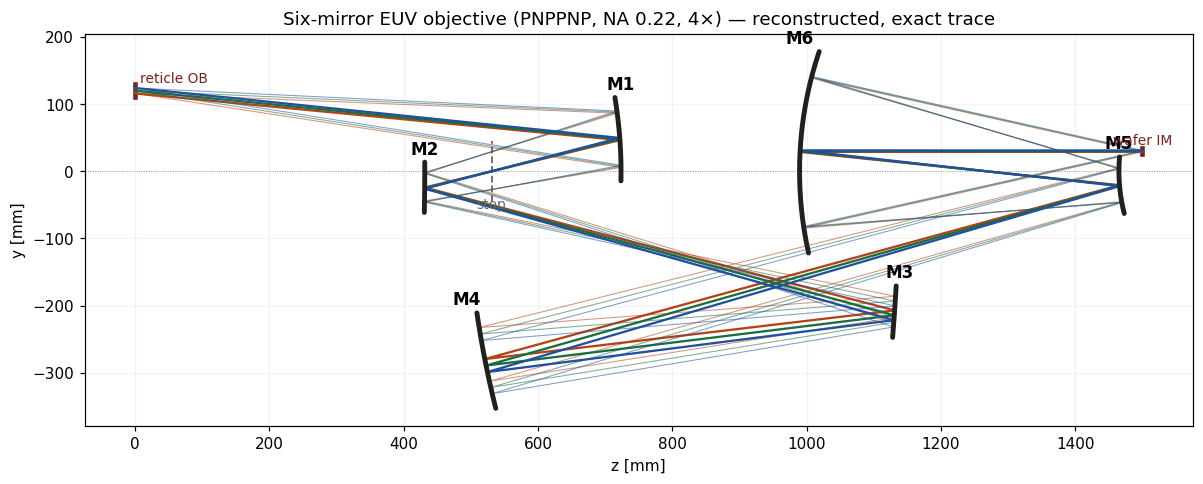

In [8]:
set_params([c for row in REC for c in row])
colors = {116.0:"#b3421b", 120.0:"#1a6e3c", 124.0:"#20509e"}
fig, ax = plt.subplots(figsize=(13, 8))

for y in FIELDS:
    th = find_chief(y)
    for off, lw, al in [(0,1.5,1.0),(NAO,0.7,0.55),(-NAO,0.7,0.55)]:
        d = np.array([0.0, np.sin(th+off), np.cos(th+off)])
        P = np.array(trace([0,y,0], d)[0])
        ax.plot(P[:,2], P[:,1], color=colors[y], lw=lw, alpha=al, zorder=3)

used = {m["name"]:[np.inf,-np.inf] for m in MIRRORS}
for y in FIELDS:
    th = find_chief(y)
    for off in np.linspace(-NAO, NAO, 9):
        P = trace([0,y,0], [0,np.sin(th+off),np.cos(th+off)])[0]
        for i, m in enumerate(MIRRORS):
            used[m["name"]][0] = min(used[m["name"]][0], P[i+1][1])
            used[m["name"]][1] = max(used[m["name"]][1], P[i+1][1])
for m in MIRRORS:
    lo, hi = used[m["name"]]; pad = 0.12*(hi-lo)+10
    yy = np.linspace(lo-pad, hi+pad, 300)
    ax.plot(m["zv"]+sag(m, yy**2), yy, color="#22201c", lw=3.2,
            solid_capstyle="round", zorder=4)
    ax.annotate(m["name"], (m["zv"], hi+pad+12), ha="center",
                fontsize=11, fontweight="bold")

ax.plot([0,0],[110,130], color="#7a1f1f", lw=3); ax.annotate("reticle OB",(8,132),fontsize=9,color="#7a1f1f")
ax.plot([Z["IM"]]*2,[26,34], color="#7a1f1f", lw=3); ax.annotate("wafer IM",(Z["IM"],40),ha="center",fontsize=9,color="#7a1f1f")
ax.plot([Z["APE"]]*2,[-45,45], color="#666", lw=1.2, ls="--"); ax.annotate("stop",(Z["APE"],-56),ha="center",fontsize=9,color="#666")
ax.axhline(0, color="#999", lw=0.6, ls=":")
ax.set_xlabel("z [mm]"); ax.set_ylabel("y [mm]"); ax.set_aspect("equal"); ax.grid(alpha=0.15)
ax.set_title("Six-mirror EUV objective (PNPPNP, NA 0.22, 4×) — reconstructed, exact trace")
plt.show()

## 7 · Spot diagrams vs. the diffraction limit

Geometric spots at the wafer for a filled pupil, compared with the Airy radius
$0.61\lambda/\mathrm{NA}$. Deep sub-Airy ⇒ the design is diffraction-limited.

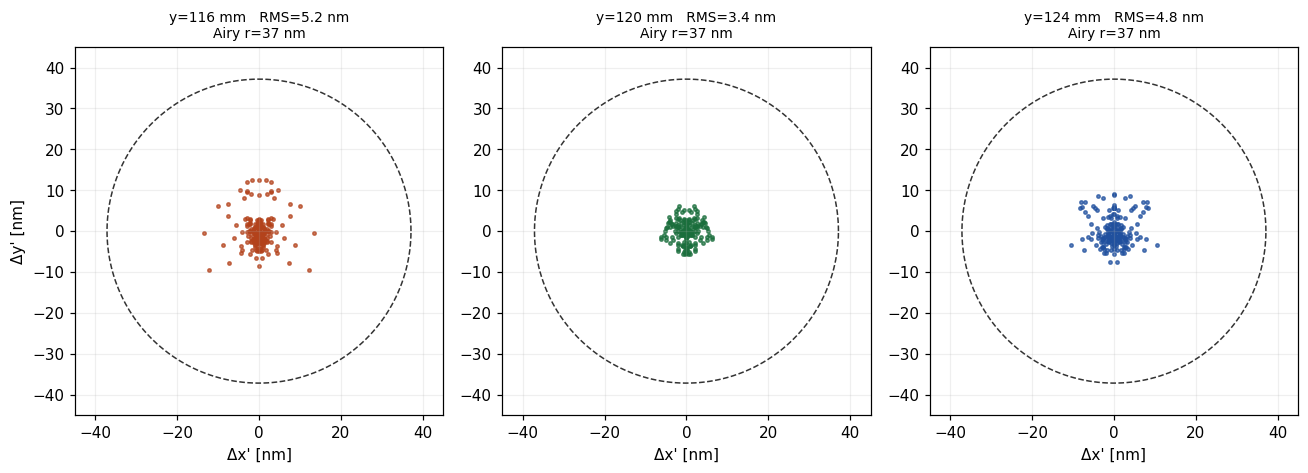

In [9]:
airy = 0.61*WAVEL/NAI*1e6         # nm
fig, axs = plt.subplots(1, 3, figsize=(12, 4.3))
for ax, y in zip(axs, FIELDS):
    th = find_chief(y); pts = []
    for py in np.linspace(-1,1,17):
        for px in np.linspace(-1,1,17):
            if px*px+py*py > 1.0: continue
            a = th + py*NAO; dx = px*NAO
            d = np.array([dx, np.sin(a), np.sqrt(1-dx*dx-np.sin(a)**2)])
            pts.append(trace([0,y,0], d)[3][:2])
    pts = np.array(pts); c = pts.mean(0)
    rms = np.sqrt(((pts-c)**2).sum(1).mean())*1e6
    ax.scatter((pts[:,0]-c[0])*1e6, (pts[:,1]-c[1])*1e6, s=5, color=colors[y], alpha=0.7)
    t = np.linspace(0,2*np.pi,200)
    ax.plot(airy*np.cos(t), airy*np.sin(t), "--", color="#333", lw=1)
    ax.set_title(f"y={y:.0f} mm   RMS={rms:.1f} nm\nAiry r={airy:.0f} nm", fontsize=9)
    ax.set_xlim(-45,45); ax.set_ylim(-45,45); ax.set_aspect("equal"); ax.grid(alpha=0.2)
    ax.set_xlabel("Δx' [nm]")
axs[0].set_ylabel("Δy' [nm]"); plt.tight_layout(); plt.show()

## 8 · Exit-pupil wavefront (the eikonal over the pupil)

For the ring-field centre we trace a dense fan, accumulate OPL, and reference
each ray to a sphere centred on the chief-ray image point. The pupil coordinate
of a ray is its arrival direction relative to the chief, normalised by NA. The
result is the wavefront error $W(u,v)$ in waves — this *is* the phase the wave
carries into the wafer.

reconstructed wavefront: RMS = 16.4 mλ, P-V = 88.5 mλ


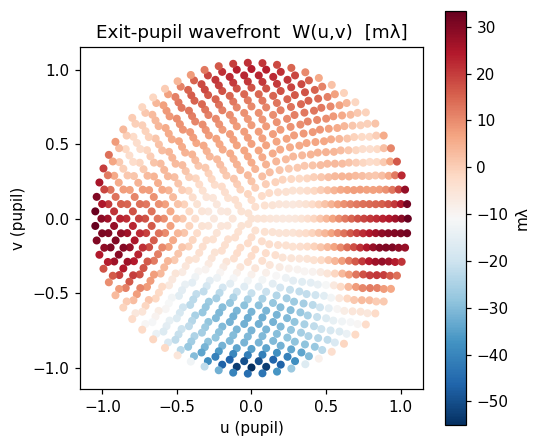

In [10]:
def pupil_wavefront(YOBJ=120.0, Rref=500.0, nring=26):
    th = find_chief(YOBJ)
    Lc, pc, dc = trace_opl([0,YOBJ,0], [0,np.sin(th),np.cos(th)])
    xi, eta, opd = [], [], []
    for r in np.linspace(0, 1.049, nring):
        for ph in np.linspace(0, 2*np.pi, max(1,int(round(64*r))), endpoint=False):
            px, py = r*np.cos(ph), r*np.sin(ph)
            a = th + py*NAO; dx = px*NAO
            d0 = np.array([dx, np.sin(a), np.sqrt(1-dx*dx-np.sin(a)**2)])
            L, pim, dim = trace_opl([0,YOBJ,0], d0)
            u = (dim[0]-dc[0])/NAI; v = (dim[1]-dc[1])/NAI
            w = pim - pc; b = np.dot(w, dim)
            s = b + np.sqrt(max(b*b - (np.dot(w,w) - Rref**2), 0.0))
            xi.append(u); eta.append(v); opd.append((L - s) - (Lc - Rref))
    xi, eta = np.array(xi), np.array(eta)
    opd = np.array(opd)/WAVEL; opd -= opd.mean()
    return xi, eta, opd

xi, eta, opd = pupil_wavefront()
print(f"reconstructed wavefront: RMS = {opd.std()*1000:.1f} mλ, "
      f"P-V = {np.ptp(opd)*1000:.1f} mλ")

fig, ax = plt.subplots(figsize=(5,4.4))
sc = ax.scatter(xi, eta, c=opd*1000, cmap="RdBu_r", s=18)
ax.set_aspect("equal"); ax.set_xlabel("u (pupil)"); ax.set_ylabel("v (pupil)")
ax.set_title("Exit-pupil wavefront  W(u,v)  [mλ]")
plt.colorbar(sc, label="mλ"); plt.tight_layout(); plt.show()

## 9 · Propagation to the wafer — scalar partially-coherent imaging

We convert OPD → pupil phase $P(u,v)=\mathbb{1}_{\rho\le1}\,e^{i2\pi W}$, then form
the aerial image by the **Abbe** method: for each source point (conventional
disc, $\sigma=0.7$) the pupil is shifted, multiplied by the mask spectrum,
inverse-transformed, and the intensities summed incoherently.

$$
I(\mathbf r)=\!\!\sum_{\text{src }\mathbf s}\!\Big|\;
\mathcal{F}^{-1}\!\big[\,\hat{\mathrm{mask}}\cdot P(\mathbf f-\mathbf s)\,\big]\Big|^{2}.
$$

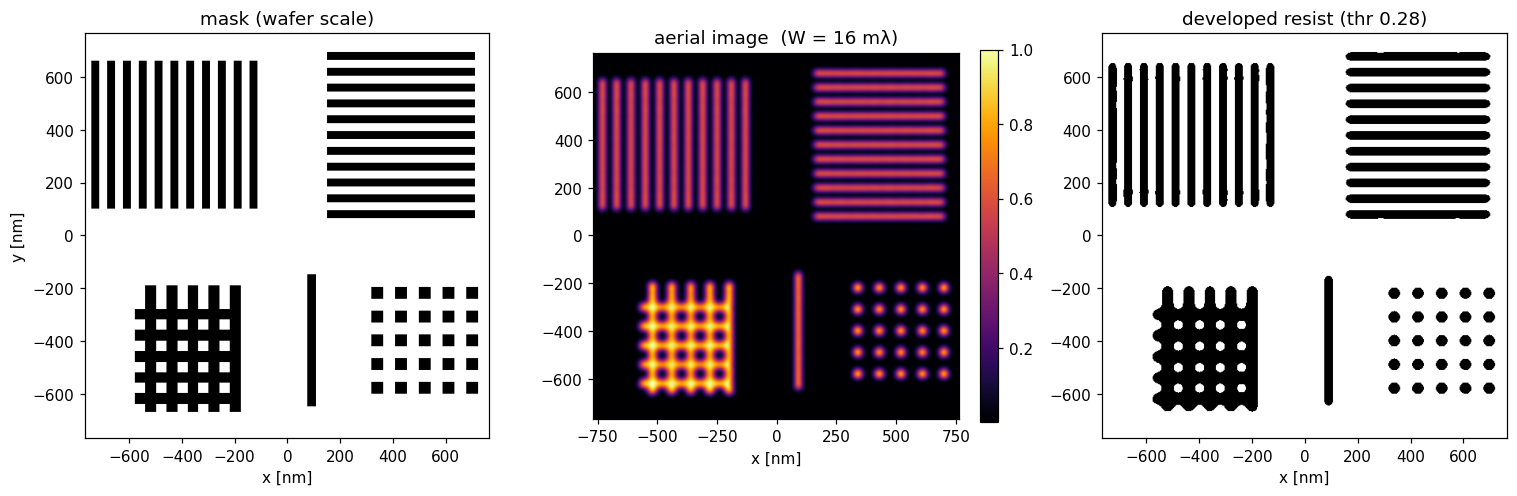

In [11]:
LAM, YOBJ, SIG = WAVEL, 120.0, 0.7
N, dxp = 512, 3.0e-6                       # 3 nm pixels; 1.536 µm field
f = np.fft.fftfreq(N, dxp); FX, FY = np.meshgrid(f, f)

# interpolate the traced wavefront onto the FFT pupil grid
U, V = FX*LAM/NAI, FY*LAM/NAI
W2 = np.nan_to_num(griddata(np.column_stack([xi,eta]), opd, (U,V),
                            method="cubic", fill_value=0.0))
RHO2 = U*U + V*V
PUP  = (RHO2 <= 1.0)*np.exp(1j*2*np.pi*W2)

# lithographic test mask (wafer scale, ideal binary amplitude)
x = (np.arange(N)-N//2)*3.0; X, Y = np.meshgrid(x, x)
mask = np.zeros((N, N))
def rect(x0,y0,w,h): mask[(np.abs(X-x0)<=w/2)&(np.abs(Y-y0)<=h/2)] = 1.0
for k in range(-5,6): rect(-430+k*60, 380, 30, 560)     # 30 nm vertical L/S
for k in range(-5,6): rect(430, 380+k*60, 560, 30)      # 30 nm horizontal L/S
for k in range(5):
    rect(-560+k*80+40, -430, 40, 480); rect(-380, -640+k*80+20, 400, 40)  # elbows
rect(90, -400, 30, 500)                                 # isolated 30 nm line
for kx in range(5):
    for ky in range(5): rect(340+kx*90, -580+ky*90, 45, 45)  # 45 nm contacts

def aerial(pupil, nsrc=5):
    M = np.fft.fft2(mask); I = np.zeros((N,N)); df = f[1]-f[0]
    for sx in np.linspace(-SIG,SIG,2*nsrc+1):
        for sy in np.linspace(-SIG,SIG,2*nsrc+1):
            if sx*sx+sy*sy > SIG*SIG: continue
            Ps = np.roll(np.roll(pupil, int(round(sy*NAI/LAM/df)),0),
                         int(round(sx*NAI/LAM/df)),1)
            I += np.abs(np.fft.ifft2(M*Ps))**2
    return I

I = aerial(PUP); I /= I.max()
THR = 0.28
ext = [x[0], x[-1], x[0], x[-1]]
fig, axs = plt.subplots(1, 3, figsize=(14, 5))
axs[0].imshow(mask, extent=ext, origin="lower", cmap="gray_r")
axs[0].set_title("mask (wafer scale)")
im = axs[1].imshow(I, extent=ext, origin="lower", cmap="inferno")
axs[1].set_title(f"aerial image  (W = {opd.std()*1000:.0f} mλ)"); plt.colorbar(im, ax=axs[1], fraction=0.046)
axs[2].imshow(I > THR, extent=ext, origin="lower", cmap="gray_r")
axs[2].set_title(f"developed resist (thr {THR})")
for a in axs: a.set_xlabel("x [nm]")
axs[0].set_ylabel("y [nm]"); plt.tight_layout(); plt.show()

## 10 · Resolving power — contrast vs. half-pitch

1-D equal line/space gratings of decreasing half-pitch through the real system.
Near the limit only the 0th and ±1st diffraction orders survive the pupil, so
the aerial image becomes a pure cosine fringe; contrast collapses at the
partially-coherent cutoff $\lambda/[2\,\mathrm{NA}(1+\sigma)]$.

In [ ]:
HPS = [60, 40, 30, 25, 22, 20, 18, 17, 16, 15]
N1, dx1 = 4096, 0.5e-6
f1 = np.fft.fftfreq(N1, dx1); x1 = (np.arange(N1)-N1//2)*0.5
def W_at(u, v):
    return np.nan_to_num(griddata(np.column_stack([xi,eta]), opd, (u,v),
                                  method="cubic", fill_value=0.0))
sxs = np.linspace(-SIG, SIG, 13); contrast = []
for hp in HPS:
    g = (np.mod(x1, 2*hp) < hp).astype(float); G = np.fft.fft(g)
    I1 = np.zeros(N1)
    for sx in sxs:
        for sy in sxs:
            if sx*sx+sy*sy > SIG*SIG: continue
            u = f1*LAM/NAI + sx; v = np.full_like(u, sy)
            ins = (u*u+v*v) <= 1.0; Wl = np.zeros_like(u)
            if ins.any(): Wl[ins] = W_at(u[ins], v[ins])
            I1 += np.abs(np.fft.ifft(G*ins*np.exp(1j*2*np.pi*Wl)))**2
    mid = slice(N1//2-800, N1//2+800)
    contrast.append((I1[mid].max()-I1[mid].min())/(I1[mid].max()+I1[mid].min()))

hp_cut = LAM*1e6/(2*NAI*(1+SIG))
fig, ax = plt.subplots(figsize=(8,4.6))
ax.plot(HPS, contrast, "o-", color="#1a6e3c", lw=1.8)
ax.axvline(hp_cut, color="#b3421b", ls="--"); ax.axhline(0.30, color="#555", ls=":")
ax.annotate(f"cutoff λ/[2·NA·(1+σ)] = {hp_cut:.1f} nm", (hp_cut, 0.66),
            color="#b3421b", ha="right", fontsize=9)
ax.set_xlim(63,13); ax.set_ylim(0,1.02); ax.grid(alpha=0.25)
ax.set_xlabel("half-pitch [nm]"); ax.set_ylabel("image contrast")
ax.set_title("Resolving power of the objective (NA 0.22, λ 13.4 nm, σ 0.7)")
plt.tight_layout(); plt.show()
for hp, c in zip(HPS, contrast): print(f"  half-pitch {hp:3d} nm -> contrast {c:.3f}")

## 11 · Toward a vectorial treatment

Everything above is **geometrical optics + scalar diffraction**. The rigorous
extension replaces the scalar pupil $P(u,v)$ with a **Jones pupil** $\mathbf J(u,v)$,
a $2\times2$ operator per pupil point accumulating the polarization-dependent
amplitude/phase of all six Bragg-multilayer reflections (each with its own
$r_s(\theta),\,r_p(\theta)$ at the AOIs computed in §3), and forms the image
from the vectorial superposition of focused plane waves (Richards–Wolf):

$$
\mathbf E(\mathbf r)\;\propto\!\!\int_{\text{pupil}}\!\!
\mathbf J(u,v)\,\hat{\mathrm{mask}}\;
e^{\,i k (\mathbf k\cdot\mathbf r)}\;\frac{du\,dv}{k_z}.
$$

At NA 0.22 the correction scales as $\mathrm{NA}^2\!\approx\!5\%$; at High-NA
0.55 it dominates image contrast. The scalar pupil built in §8 is exactly the
object the Jones pupil generalises — the same operator structure
$\tilde\zeta^{f}=\mu(r)e^{i\Delta(r)}\tilde\zeta$ that maps input to focal-plane
polarization. The `trace_opl` fan already delivers per-ray directions and AOIs,
so the only additions are (i) the $s/p$ basis at each surface and (ii) the
multilayer Fresnel stack — a clean next module.